In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score
import re
import string
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


In [5]:
email_df = pd.read_csv("C:/Users/Lenovo/Downloads/spam.csv", encoding='latin-1')

print("Dataset loaded successfully!")
print(f"Dataset Shape: {email_df.shape}")
print("\nFirst 10 rows:")
print(email_df.head(10))
print("\nColumn Names:")
print(email_df.columns.tolist())
print("\nData Types:")
print(email_df.dtypes)

Dataset loaded successfully!
Dataset Shape: (5572, 5)

First 10 rows:
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   
5  spam  FreeMsg Hey there darling it's been 3 week's n...        NaN   
6   ham  Even my brother is not like to speak with me. ...        NaN   
7   ham  As per your request 'Melle Melle (Oru Minnamin...        NaN   
8  spam  WINNER!! As a valued network customer you have...        NaN   
9  spam  Had your mobile 11 months or more? U R entitle...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        Na

In [6]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)
print(email_df.info())

print("\n" + "="*70)
print("FIRST FEW SAMPLES")
print("="*70)
for idx in range(min(3, len(email_df))):
    print(f"\nSample {idx+1}:")
    for col in email_df.columns:
        print(f"  {col}: {email_df.iloc[idx][col]}")

print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)
print(email_df.isnull().sum())

print("\n" + "="*70)
print("UNIQUE VALUES PER COLUMN")
print("="*70)
for col in email_df.columns:
    unique_count = email_df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    if unique_count <= 10:
        print(f"  Values: {email_df[col].unique()}")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None

FIRST FEW SAMPLES

Sample 1:
  v1: ham
  v2: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  Unnamed: 2: nan
  Unnamed: 3: nan
  Unnamed: 4: nan

Sample 2:
  v1: ham
  v2: Ok lar... Joking wif u oni...
  Unnamed: 2: nan
  Unnamed: 3: nan
  Unnamed: 4: nan

Sample 3:
  v1: spam
  v2: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  Unnamed: 2: nan
  Unnamed: 3: nan
  Un

In [7]:
text_column = None
max_avg_length = 0

for col in email_df.columns:
    if email_df[col].dtype == 'object':
        avg_length = email_df[col].astype(str).str.len().mean()
        if avg_length > max_avg_length:
            max_avg_length = avg_length
            text_column = col

print(f"✓ Text column detected: {text_column}")

label_column = None
for col in email_df.columns:
    if col != text_column and email_df[col].nunique() <= 5:
        label_column = col
        break

if text_column is None or label_column is None:
    print("⚠ Could not detect columns. Please specify manually above.")
    print(f"Columns available: {email_df.columns.tolist()}")
else:
    print(f"✓ Label column detected: {label_column}")
    print(f"\nLabel distribution:")
    print(email_df[label_column].value_counts())

✓ Text column detected: v2
✓ Label column detected: v1

Label distribution:
v1
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
df_clean = email_df[[text_column, label_column]].copy()
df_clean.columns = ['text', 'label']

print("="*70)
print("DATA CLEANING")
print("="*70)

missing_before = df_clean.isnull().sum().sum()
print(f"Missing values before: {missing_before}")

df_clean = df_clean.dropna()

print(f"Missing values after: {df_clean.isnull().sum().sum()}")

duplicates_before = df_clean.duplicated().sum()
print(f"\nDuplicates before: {duplicates_before}")

df_clean = df_clean.drop_duplicates()

print(f"Duplicates after: {df_clean.duplicated().sum()}")

unique_labels = df_clean['label'].unique()
print(f"\nOriginal labels: {unique_labels}")

spam_indicators = ['spam', '1', 'yes', 'true']
ham_indicators = ['ham', '0', 'no', 'false']

df_clean['label'] = df_clean['label'].astype(str).str.lower().str.strip()

def standardize_label(label):
    label_lower = str(label).lower().strip()
    if any(indicator in label_lower for indicator in spam_indicators):
        return 'spam'
    else:
        return 'ham'

df_clean['label'] = df_clean['label'].apply(standardize_label)

print(f"\nStandardized labels: {df_clean['label'].unique()}")
print(f"\n✓ Clean dataset shape: {df_clean.shape}")

DATA CLEANING
Missing values before: 0
Missing values after: 0

Duplicates before: 403
Duplicates after: 0

Original labels: ['ham' 'spam']

Standardized labels: ['ham' 'spam']

✓ Clean dataset shape: (5169, 2)


In [25]:
label_counts = df_clean['label'].value_counts()

print("="*70)
print("CLASS DISTRIBUTION")
print("="*70)
print(label_counts)
print(f"\nSpam: {label_counts.get('spam', 0)} ({label_counts.get('spam', 0)/len(df_clean)*100:.1f}%)")
print(f"Ham: {label_counts.get('ham', 0)} ({label_counts.get('ham', 0)/len(df_clean)*100:.1f}%)")



CLASS DISTRIBUTION
label
ham     4516
spam     653
Name: count, dtype: int64

Spam: 653 (12.6%)
Ham: 4516 (87.4%)


In [10]:
def preprocess_text(text):
    text = str(text).lower()
    
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    text = re.sub(r'\S+@\S+', '', text)
    
    text = re.sub(r'\d{10}|\d{3}[-.\s]\d{3}[-.\s]\d{4}', '', text)
    
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = ' '.join(text.split())
    
    return text

print("Preprocessing text data...")
df_clean['cleaned_text'] = df_clean['text'].apply(preprocess_text)

print("✓ Text preprocessing completed!")
print("\nExample of preprocessing:")
print("─"*70)
print("ORIGINAL:")
print(df_clean['text'].iloc[0][:200])
print("\nCLEANED:")
print(df_clean['cleaned_text'].iloc[0][:200])

Preprocessing text data...
✓ Text preprocessing completed!

Example of preprocessing:
──────────────────────────────────────────────────────────────────────
ORIGINAL:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

CLEANED:
go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


TEXT STATISTICS BY CLASS

SPAM EMAILS:
  Average text length: 137.9 characters
  Average word count: 20.9 words
  Min words: 1
  Max words: 32

HAM EMAILS:
  Average text length: 70.5 characters
  Average word count: 13.7 words
  Min words: 0
  Max words: 171


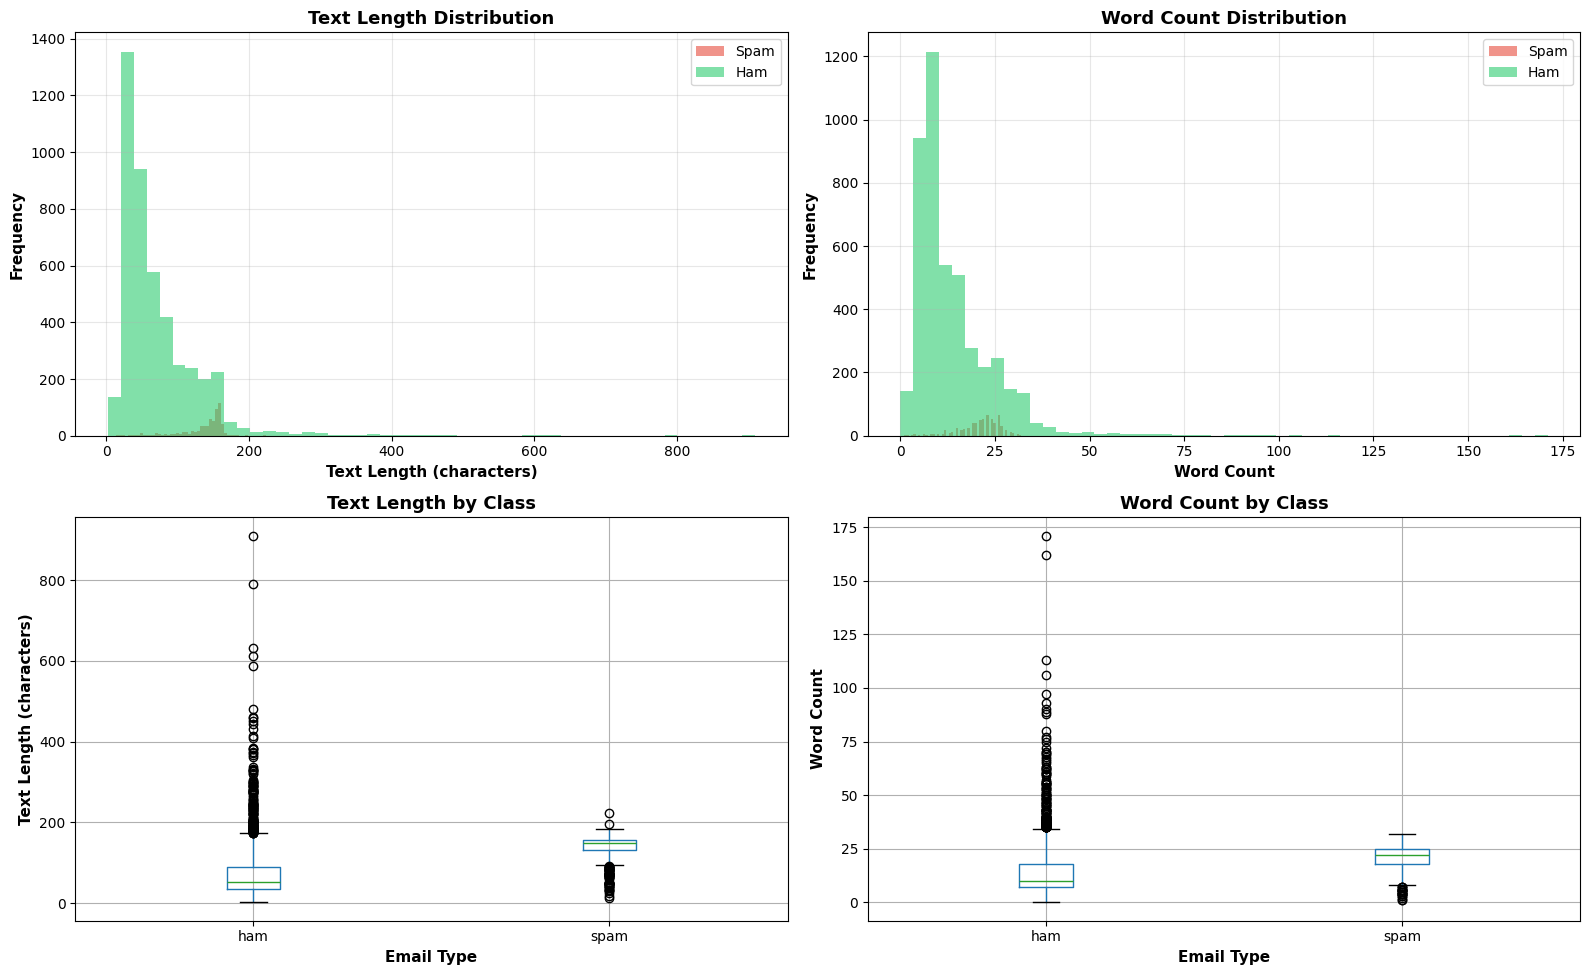

In [11]:
df_clean['text_length'] = df_clean['text'].apply(len)
df_clean['word_count'] = df_clean['cleaned_text'].apply(lambda x: len(x.split()))
df_clean['char_count'] = df_clean['cleaned_text'].apply(len)

print("="*70)
print("TEXT STATISTICS BY CLASS")
print("="*70)

for label in ['spam', 'ham']:
    subset = df_clean[df_clean['label'] == label]
    print(f"\n{label.upper()} EMAILS:")
    print(f"  Average text length: {subset['text_length'].mean():.1f} characters")
    print(f"  Average word count: {subset['word_count'].mean():.1f} words")
    print(f"  Min words: {subset['word_count'].min()}")
    print(f"  Max words: {subset['word_count'].max()}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Text Statistics Analysis', fontsize=16, fontweight='bold')

for label in ['spam', 'ham']:
    data = df_clean[df_clean['label'] == label]['text_length']
    color = '#e74c3c' if label == 'spam' else '#2ecc71'
    axes[0, 0].hist(data, bins=50, alpha=0.6, label=label.capitalize(), color=color)

axes[0, 0].set_xlabel('Text Length (characters)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Text Length Distribution', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

for label in ['spam', 'ham']:
    data = df_clean[df_clean['label'] == label]['word_count']
    color = '#e74c3c' if label == 'spam' else '#2ecc71'
    axes[0, 1].hist(data, bins=50, alpha=0.6, label=label.capitalize(), color=color)

axes[0, 1].set_xlabel('Word Count', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

df_clean.boxplot(column='text_length', by='label', ax=axes[1, 0])
axes[1, 0].set_title('Text Length by Class', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Email Type', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Text Length (characters)', fontsize=11, fontweight='bold')
plt.suptitle('')

df_clean.boxplot(column='word_count', by='label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Class', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Email Type', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Word Count', fontsize=11, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.show()

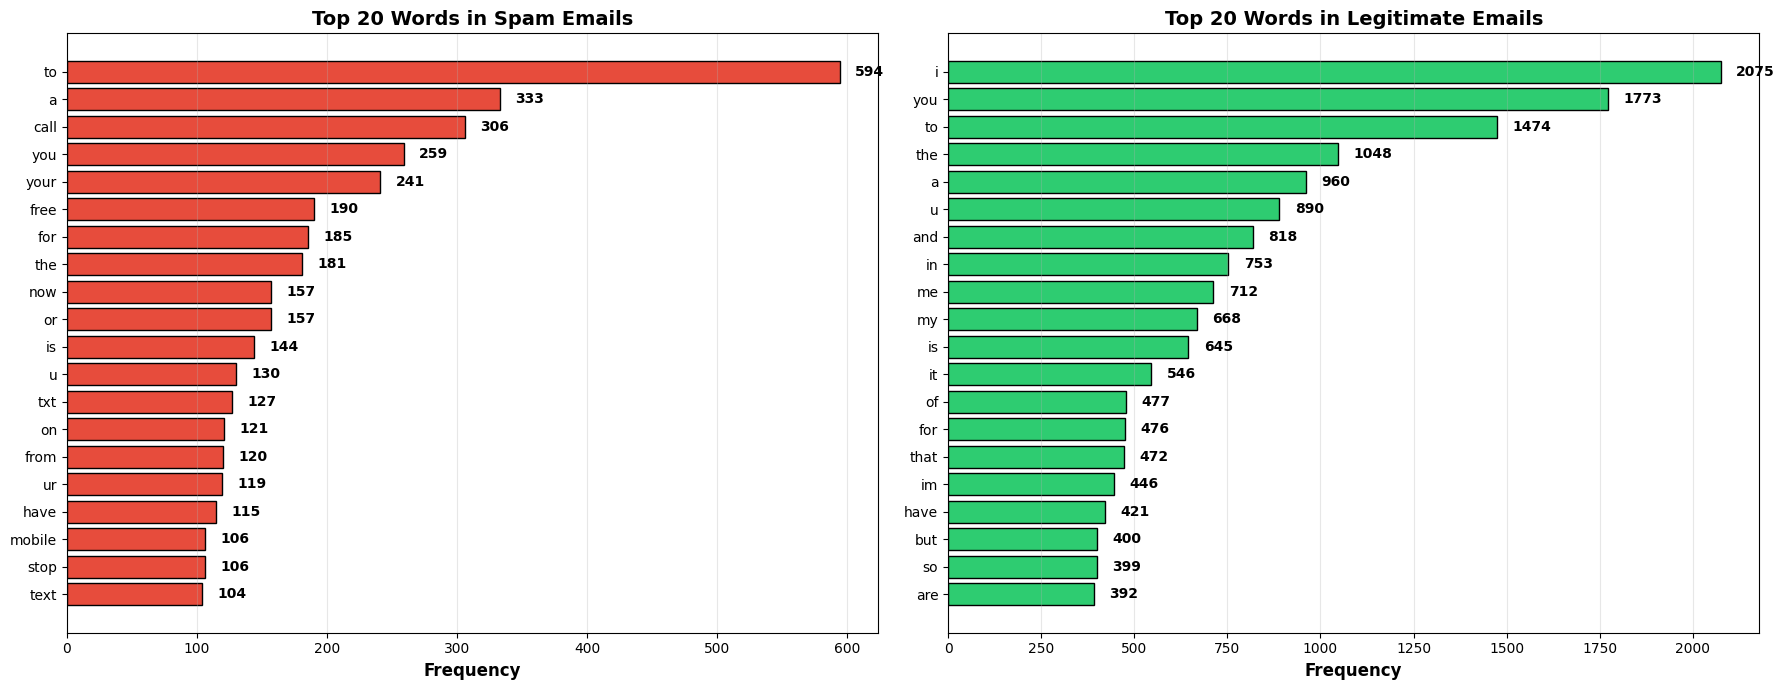


TOP 10 WORDS IN SPAM EMAILS
to: 594
a: 333
call: 306
you: 259
your: 241
free: 190
for: 185
the: 181
now: 157
or: 157

TOP 10 WORDS IN LEGITIMATE EMAILS
i: 2075
you: 1773
to: 1474
the: 1048
a: 960
u: 890
and: 818
in: 753
me: 712
my: 668


In [12]:
def get_top_words(text_series, n=20):
    all_words = ' '.join(text_series).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

spam_words = get_top_words(df_clean[df_clean['label'] == 'spam']['cleaned_text'], 20)
ham_words = get_top_words(df_clean[df_clean['label'] == 'ham']['cleaned_text'], 20)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

spam_df = pd.DataFrame(spam_words, columns=['word', 'count'])
axes[0].barh(spam_df['word'], spam_df['count'], color='#e74c3c', edgecolor='black')
axes[0].set_title('Top 20 Words in Spam Emails', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3, axis='x')

for i, v in enumerate(spam_df['count']):
    axes[0].text(v + max(spam_df['count'])*0.02, i, str(v), 
                va='center', fontweight='bold')

ham_df = pd.DataFrame(ham_words, columns=['word', 'count'])
axes[1].barh(ham_df['word'], ham_df['count'], color='#2ecc71', edgecolor='black')
axes[1].set_title('Top 20 Words in Legitimate Emails', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Frequency', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(alpha=0.3, axis='x')

for i, v in enumerate(ham_df['count']):
    axes[1].text(v + max(ham_df['count'])*0.02, i, str(v), 
                va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("TOP 10 WORDS IN SPAM EMAILS")
print("="*70)
for word, count in spam_words[:10]:
    print(f"{word}: {count}")

print("\n" + "="*70)
print("TOP 10 WORDS IN LEGITIMATE EMAILS")
print("="*70)
for word, count in ham_words[:10]:
    print(f"{word}: {count}")

In [13]:
X = df_clean['cleaned_text']
y = df_clean['label']

y_encoded = (y == 'spam').astype(int)

print("="*70)
print("DATA PREPARATION FOR MODELING")
print("="*70)
print(f"Total samples: {len(X)}")
print(f"Spam samples: {(y_encoded == 1).sum()}")
print(f"Ham samples: {(y_encoded == 0).sum()}")

test_size = 0.25
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=test_size, random_state=42, stratify=y_encoded
)

print(f"\nTraining set: {len(X_train)} samples ({(1-test_size)*100:.0f}%)")
print(f"Testing set: {len(X_test)} samples ({test_size*100:.0f}%)")
print(f"\nTraining set distribution:")
print(f"  Spam: {(y_train == 1).sum()}")
print(f"  Ham: {(y_train == 0).sum()}")
print(f"\nTesting set distribution:")
print(f"  Spam: {(y_test == 1).sum()}")
print(f"  Ham: {(y_test == 0).sum()}")

DATA PREPARATION FOR MODELING
Total samples: 5169
Spam samples: 653
Ham samples: 4516

Training set: 3876 samples (75%)
Testing set: 1293 samples (25%)

Training set distribution:
  Spam: 490
  Ham: 3386

Testing set distribution:
  Spam: 163
  Ham: 1130


In [14]:
print("\n" + "="*70)
print("FEATURE EXTRACTION (TF-IDF)")
print("="*70)

tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"✓ TF-IDF vectorization completed!")
print(f"Training feature matrix shape: {X_train_tfidf.shape}")
print(f"Testing feature matrix shape: {X_test_tfidf.shape}")
print(f"Number of features: {X_train_tfidf.shape[1]}")
print(f"Vocabulary size: {len(tfidf_vectorizer.vocabulary_)}")

feature_names = tfidf_vectorizer.get_feature_names_out()
print(f"\nSample features: {feature_names[:20]}")


FEATURE EXTRACTION (TF-IDF)
✓ TF-IDF vectorization completed!
Training feature matrix shape: (3876, 3000)
Testing feature matrix shape: (1293, 3000)
Number of features: 3000
Vocabulary size: 3000

Sample features: ['aah' 'abi' 'ability' 'abiola' 'able' 'abt' 'abt tht' 'abt ur' 'aburo'
 'aburo enjoy' 'ac' 'acc' 'accept' 'access' 'accidentally'
 'accidentally deleted' 'account' 'account details' 'account ltgt'
 'account number']


In [15]:
models = {
    'Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(kernel='linear', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=20)
}

model_results = {}

print("\n" + "="*70)
print("TRAINING SPAM DETECTION MODELS")
print("="*70)

for model_name, model in models.items():
    print(f"\n{'─'*70}")
    print(f"Training: {model_name}")
    print(f"{'─'*70}")
    
    model.fit(X_train_tfidf, y_train)
    
    y_pred_train = model.predict(X_train_tfidf)
    y_pred_test = model.predict(X_test_tfidf)
    
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    model_results[model_name] = {
        'model': model,
        'train_accuracy': train_accuracy,
        'test_accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'predictions': y_pred_test
    }
    
    print(f"Training Accuracy: {train_accuracy*100:.2f}%")
    print(f"Testing Accuracy: {test_accuracy*100:.2f}%")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")


TRAINING SPAM DETECTION MODELS

──────────────────────────────────────────────────────────────────────
Training: Naive Bayes
──────────────────────────────────────────────────────────────────────
Training Accuracy: 97.94%
Testing Accuracy: 96.83%
Precision: 0.9919
Recall: 0.7546
F1-Score: 0.8571

──────────────────────────────────────────────────────────────────────
Training: Logistic Regression
──────────────────────────────────────────────────────────────────────
Training Accuracy: 96.72%
Testing Accuracy: 95.20%
Precision: 0.9903
Recall: 0.6258
F1-Score: 0.7669

──────────────────────────────────────────────────────────────────────
Training: Support Vector Machine
──────────────────────────────────────────────────────────────────────
Training Accuracy: 98.99%
Testing Accuracy: 97.53%
Precision: 0.9852
Recall: 0.8160
F1-Score: 0.8926

──────────────────────────────────────────────────────────────────────
Training: Random Forest
───────────────────────────────────────────────────────

In [19]:
best_model_name = max(model_results, key=lambda x: model_results[x]['f1_score'])
best_model_info = model_results[best_model_name]

print("\n" + "="*70)
print(f"🏆 BEST MODEL: {best_model_name}")
print("="*70)
print(f"Accuracy: {best_model_info['test_accuracy']*100:.2f}%")
print(f"Precision: {best_model_info['precision']*100:.2f}%")
print(f"Recall: {best_model_info['recall']*100:.2f}%")
print(f"F1-Score: {best_model_info['f1_score']*100:.2f}%")

print("\n" + "─"*70)
print("DETAILED CLASSIFICATION REPORT")
print("─"*70)
print(classification_report(
    y_test, 
    best_model_info['predictions'],
    target_names=['Ham (Legitimate)', 'Spam']
))


🏆 BEST MODEL: Support Vector Machine
Accuracy: 97.53%
Precision: 98.52%
Recall: 81.60%
F1-Score: 89.26%

──────────────────────────────────────────────────────────────────────
DETAILED CLASSIFICATION REPORT
──────────────────────────────────────────────────────────────────────
                  precision    recall  f1-score   support

Ham (Legitimate)       0.97      1.00      0.99      1130
            Spam       0.99      0.82      0.89       163

        accuracy                           0.98      1293
       macro avg       0.98      0.91      0.94      1293
    weighted avg       0.98      0.98      0.97      1293




CONFUSION MATRIX ANALYSIS
True Negatives (Correctly identified Ham): 1128
False Positives (Ham classified as Spam): 2
False Negatives (Spam classified as Ham): 30
True Positives (Correctly identified Spam): 133

False Positive Rate: 0.18%
False Negative Rate: 18.40%


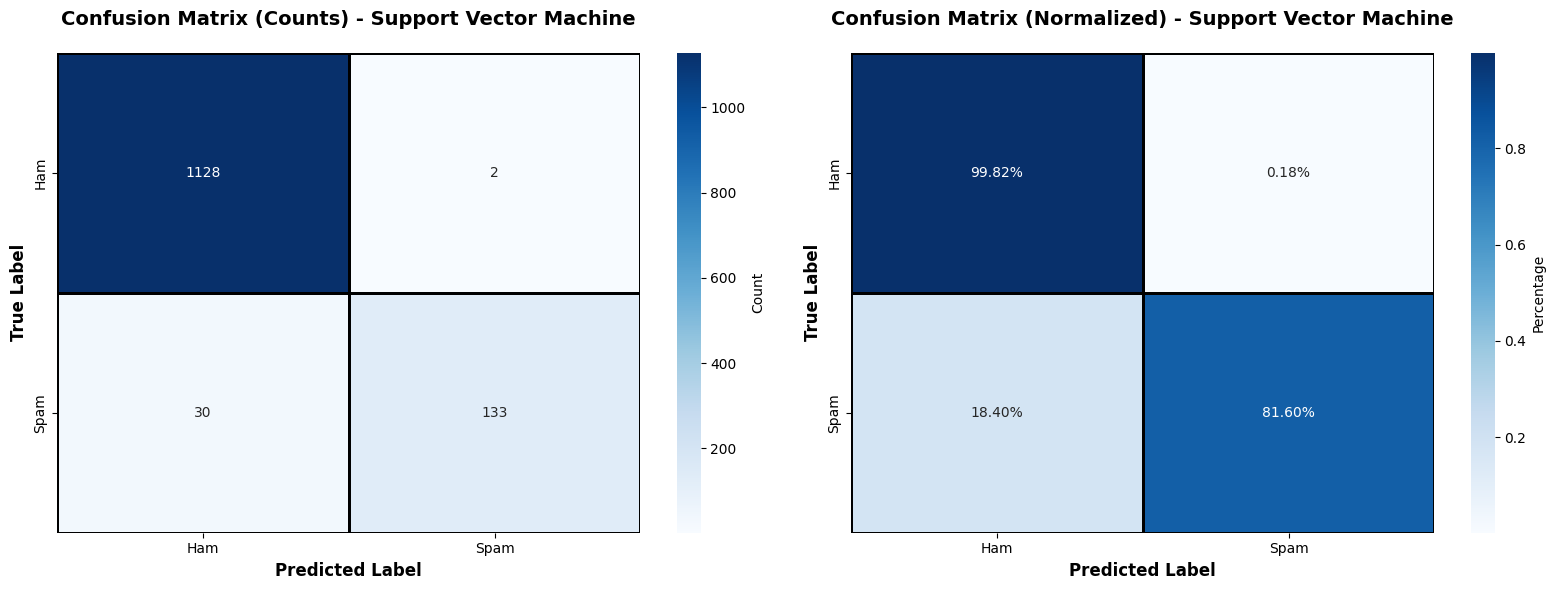

In [20]:
cm = confusion_matrix(y_test, best_model_info['predictions'])

tn, fp, fn, tp = cm.ravel()

print("\n" + "="*70)
print("CONFUSION MATRIX ANALYSIS")
print("="*70)
print(f"True Negatives (Correctly identified Ham): {tn}")
print(f"False Positives (Ham classified as Spam): {fp}")
print(f"False Negatives (Spam classified as Ham): {fn}")
print(f"True Positives (Correctly identified Spam): {tp}")

print(f"\nFalse Positive Rate: {fp/(fp+tn)*100:.2f}%")
print(f"False Negative Rate: {fn/(fn+tp)*100:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'],
            cbar_kws={'label': 'Count'},
            linewidths=2, linecolor='black',
            ax=axes[0])
axes[0].set_title(f'Confusion Matrix (Counts) - {best_model_name}', 
                 fontsize=14, fontweight='bold', pad=20)
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'],
            cbar_kws={'label': 'Percentage'},
            linewidths=2, linecolor='black',
            ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Normalized) - {best_model_name}', 
                 fontsize=14, fontweight='bold', pad=20)
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
print("\n" + "="*70)
print("ERROR ANALYSIS")
print("="*70)

y_test_array = y_test.values
predictions = best_model_info['predictions']
misclassified_indices = np.where(y_test_array != predictions)[0]

print(f"Total misclassified: {len(misclassified_indices)}")
print(f"Misclassification rate: {len(misclassified_indices)/len(y_test)*100:.2f}%")

X_test_list = X_test.tolist()
y_test_list = y_test_array.tolist()

false_positives = np.where((y_test_array == 0) & (predictions == 1))[0]
print(f"\n{'─'*70}")
print(f"FALSE POSITIVES (Ham emails classified as Spam): {len(false_positives)}")
print(f"{'─'*70}")

for i, idx in enumerate(false_positives[:3]):
    print(f"\nExample {i+1}:")
    print(f"Text: {X_test_list[idx][:200]}...")
    print(f"Actual: Ham, Predicted: Spam")

false_negatives = np.where((y_test_array == 1) & (predictions == 0))[0]
print(f"\n{'─'*70}")
print(f"FALSE NEGATIVES (Spam emails classified as Ham): {len(false_negatives)}")
print(f"{'─'*70}")

for i, idx in enumerate(false_negatives[:3]):
    print(f"\nExample {i+1}:")
    print(f"Text: {X_test_list[idx][:200]}...")
    print(f"Actual: Spam, Predicted: Ham")


ERROR ANALYSIS
Total misclassified: 32
Misclassification rate: 2.47%

──────────────────────────────────────────────────────────────────────
FALSE POSITIVES (Ham emails classified as Spam): 2
──────────────────────────────────────────────────────────────────────

Example 1:
Text: k k sms chat with me...
Actual: Ham, Predicted: Spam

Example 2:
Text: ok ur typical reply...
Actual: Ham, Predicted: Spam

──────────────────────────────────────────────────────────────────────
FALSE NEGATIVES (Spam emails classified as Ham): 30
──────────────────────────────────────────────────────────────────────

Example 1:
Text: burger king wanna play footy at a top stadium get burger king before st sept and go large or super with cocacola and walk out a winner...
Actual: Spam, Predicted: Ham

Example 2:
Text: we currently have a message awaiting your collection to collect your message just call...
Actual: Spam, Predicted: Ham

Example 3:
Text: want explicit sex in secs ring now costs pmin...
Actual: Spa

In [22]:
print("\n" + "="*70)
print("SPAM DETECTION ON NEW EMAILS")
print("="*70)

sample_indices = np.random.choice(len(X_test), size=min(10, len(X_test)), replace=False)
sample_emails = [X_test_list[i] for i in sample_indices]
sample_actuals = [y_test_list[i] for i in sample_indices]

sample_cleaned = [preprocess_text(email) for email in sample_emails]
sample_tfidf = tfidf_vectorizer.transform(sample_cleaned)
sample_predictions = best_model_info['model'].predict(sample_tfidf)

for i in range(len(sample_indices)):
    actual_label = 'SPAM' if sample_actuals[i] == 1 else 'HAM'
    pred_label = 'SPAM' if sample_predictions[i] == 1 else 'HAM'
    
    emoji = "🚨" if sample_predictions[i] == 1 else "✅"
    correct = "✓" if sample_actuals[i] == sample_predictions[i] else "✗"
    
    print(f"\n{'─'*70}")
    print(f"Email {i+1} {correct}:")
    print(f"Text: {sample_emails[i][:150]}...")
    print(f"Actual: {actual_label}")
    print(f"Predicted: {emoji} {pred_label}")

sample_accuracy = accuracy_score(sample_actuals, sample_predictions)
print(f"\n{'='*70}")
print(f"Sample Accuracy: {sample_accuracy*100:.2f}%")


SPAM DETECTION ON NEW EMAILS

──────────────────────────────────────────────────────────────────────
Email 1 ✓:
Text: the last thing i ever wanted to do was hurt you and i didnt think it would have youd laugh be embarassed delete the tag and keep going but as far as i...
Actual: HAM
Predicted: ✅ HAM

──────────────────────────────────────────────────────────────────────
Email 2 ✓:
Text: good afternoon my love how goes that day i hope maybe you got some leads on a job i think of you boytoy and send you a passionate kiss from across the...
Actual: HAM
Predicted: ✅ HAM

──────────────────────────────────────────────────────────────────────
Email 3 ✓:
Text: is it your yahoo boys that bring in the perf or legal...
Actual: HAM
Predicted: ✅ HAM

──────────────────────────────────────────────────────────────────────
Email 4 ✓:
Text: i keep seeing weird shit and bein all woah then realising its actually reasonable and im all oh...
Actual: HAM
Predicted: ✅ HAM

─────────────────────────────────

In [23]:
if best_model_name == 'Naive Bayes':
    feature_log_prob = best_model_info['model'].feature_log_prob_
    feature_names = tfidf_vectorizer.get_feature_names_out()
    
    spam_prob = feature_log_prob[1]
    ham_prob = feature_log_prob[0]
    importance = spam_prob - ham_prob
    
    top_spam_indices = np.argsort(importance)[-20:][::-1]
    top_spam_features = [(feature_names[i], importance[i]) for i in top_spam_indices]
    
    print("\n" + "="*70)
    print("TOP 20 SPAM INDICATOR WORDS")
    print("="*70)
    
    spam_indicators_df = pd.DataFrame(top_spam_features, columns=['Word', 'Score'])
    
    plt.figure(figsize=(12, 8))
    bars = plt.barh(spam_indicators_df['Word'], spam_indicators_df['Score'], 
                    color='#e74c3c', edgecolor='black')
    plt.xlabel('Spam Indicator Score', fontsize=12, fontweight='bold')
    plt.title('Top 20 Words Indicating Spam', fontsize=14, fontweight='bold', pad=20)
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    for word, score in top_spam_features:
        print(f"{word}: {score:.4f}")

In [24]:
import pickle

model_filename = f'best_spam_detector_{best_model_name.replace(" ", "_").lower()}.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_model_info['model'], file)

vectorizer_filename = 'spam_tfidf_vectorizer.pkl'
with open(vectorizer_filename, 'wb') as file:
    pickle.dump(tfidf_vectorizer, file)

print(f"\n✓ Model saved as: {model_filename}")
print(f"✓ Vectorizer saved as: {vectorizer_filename}")

import json
metadata = {
    'model_name': best_model_name,
    'test_accuracy': float(best_model_info['test_accuracy']),
    'precision': float(best_model_info['precision']),
    'recall': float(best_model_info['recall']),
    'f1_score': float(best_model_info['f1_score'])
}

with open('spam_model_metadata.json', 'w') as file:
    json.dump(metadata, file, indent=4)

print(f"✓ Metadata saved as: spam_model_metadata.json")

print("\n" + "="*70)
print("TO USE THIS MODEL LATER:")
print("="*70)
print(f"""
with open('{model_filename}', 'rb') as file:
    spam_detector = pickle.load(file)

with open('{vectorizer_filename}', 'rb') as file:
    vectorizer = pickle.load(file)

new_email = "Your email text here"
cleaned = preprocess_text(new_email)
vectorized = vectorizer.transform([cleaned])
prediction = spam_detector.predict(vectorized)
""")


✓ Model saved as: best_spam_detector_support_vector_machine.pkl
✓ Vectorizer saved as: spam_tfidf_vectorizer.pkl
✓ Metadata saved as: spam_model_metadata.json

TO USE THIS MODEL LATER:

with open('best_spam_detector_support_vector_machine.pkl', 'rb') as file:
    spam_detector = pickle.load(file)

with open('spam_tfidf_vectorizer.pkl', 'rb') as file:
    vectorizer = pickle.load(file)

new_email = "Your email text here"
cleaned = preprocess_text(new_email)
vectorized = vectorizer.transform([cleaned])
prediction = spam_detector.predict(vectorized)

